In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Flatten, Dense, Dropout
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D, Add
from tensorflow.keras.optimizers import Adam

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Self-attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Add()([x, inputs])
    x = LayerNormalization(epsilon=1e-6)(x)

    # Feed-forward
    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dropout(dropout)(x_ff)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    x = Add()([x_ff, x])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_1d_hsi_transformer_classifier(input_shape, num_classes):
    inputs = Input(shape=(input_shape, 1))

    # Warstwa wejściowa (opcjonalna projekcja do wyższej przestrzeni)
    x = Dense(64)(inputs)

    # Transformer encoder blocks (można zwiększyć liczbę powtórzeń)
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

    # Pooling + klasyfikacja
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    
    return model

In [6]:
# Load data
data = sio.loadmat('../data/data/Indian_pines_NS_data.mat')
gt_data = sio.loadmat('../data/gt/Indian_pines_NS_gt.mat')

# Extract hyperspectral image and ground truth
hyper_image = data[list(data.keys())[-1]]  # Assuming last key contains data
ground_truth = gt_data[list(gt_data.keys())[-1]]  # Assuming last key contains ground truth
h, w, p = hyper_image.shape
print(hyper_image.shape)

reshaped_image = hyper_image.reshape(hyper_image.shape[0] * hyper_image.shape[1], hyper_image.shape[2])
reshaped_ground_truth = ground_truth.reshape(ground_truth.shape[0] * ground_truth.shape[1])


(2678, 614, 220)


In [7]:
class_counts = np.bincount(reshaped_ground_truth)
valid_classes = np.where(class_counts > 5000)[0]

mask = np.isin(reshaped_ground_truth, valid_classes)
reshaped_image = reshaped_image[mask]
reshaped_ground_truth = reshaped_ground_truth[mask]




# Remap labels to be sequential
unique_labels, remapped_labels = np.unique(reshaped_ground_truth, return_inverse=True)





#Usuwanie tła
non_zero_indices = remapped_labels != 0
reshaped_image = reshaped_image[non_zero_indices]
remapped_labels = remapped_labels[non_zero_indices]

# Ponownie zakoduj etykiety jako one-hot
unique_labels, remapped_labels = np.unique(remapped_labels, return_inverse=True)





num_classes = len(unique_labels)
print(num_classes)
y_one_hot = to_categorical(remapped_labels, num_classes=num_classes)



# Filter out pixels with no class (assuming class 0 is the "no class" label)
valid_indices = reshaped_ground_truth > 0
background_indices = reshaped_ground_truth == 0

# Downsample each class to a maximum of 5000 samples
filtered_image = []
filtered_labels = []

for class_label in range(0, num_classes):  # Start from 1 to exclude class 0
    class_indices = np.where(remapped_labels == class_label)[0]
    class_indices = class_indices[class_indices != 0]
    if len(class_indices) > 5000:
        sampled_indices = resample(
            class_indices,
            n_samples=5000,
            random_state=42,
            replace=False
        )
    else:
        sampled_indices = class_indices

    filtered_image.append(reshaped_image[sampled_indices])
    filtered_labels.append(y_one_hot[sampled_indices])

# Combine all classes
filtered_image = np.vstack(filtered_image)
# Remove class 0 from the filtered labels and images


# Combine all classes
filtered_image = np.vstack(filtered_image)
filtered_labels = np.vstack(filtered_labels)  # Ensure labels are also combined into a single array

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(filtered_image, filtered_labels, test_size=0.3, random_state=42)


17


In [8]:
y_train.shape

(59500, 17)

In [39]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Tworzenie modelu Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train.argmax(axis=1))  # Dopasowanie modelu (y_train w formie etykiet)

# Predykcja na zbiorze testowym
y_pred_gb = gb_model.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test.argmax(axis=1), y_pred_gb):.2f}")

# Wyświetlenie znaczenia cech
feature_importances = gb_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importance from Gradient Boosting')
plt.show()

KeyboardInterrupt: 

In [9]:


# Save feature importances to a .npy file
# np.save("feature_importances.npy", feature_importances)

# Load the saved feature importances
feature_importances = np.load("feature_importances.npy")
print(feature_importances)

[0.02439022 0.02573836 0.02559139 0.02287448 0.01246065 0.01783166
 0.02035941 0.01195743 0.00466317 0.00472579 0.00362153 0.00460772
 0.00213223 0.00245616 0.00405659 0.00386154 0.00518583 0.00114822
 0.00093014 0.00082192 0.0007733  0.00085747 0.00060578 0.00117498
 0.00109281 0.00361223 0.0025372  0.00809428 0.01073399 0.00391022
 0.00418444 0.03332188 0.01351975 0.00644077 0.01137879 0.00706543
 0.0021354  0.00555291 0.00690608 0.00439402 0.00528025 0.004441
 0.00269743 0.00529038 0.00100508 0.00073038 0.00086693 0.0005628
 0.00177533 0.00238533 0.00173692 0.00484239 0.0017157  0.0011633
 0.00073784 0.00141607 0.0008493  0.00719177 0.00655746 0.00153257
 0.00070728 0.00106421 0.0007615  0.00118197 0.00096396 0.00163336
 0.00261174 0.00170027 0.00059418 0.00158928 0.00083231 0.00284209
 0.00170217 0.00096773 0.0003413  0.00254146 0.00677905 0.00952482
 0.00210188 0.00400612 0.00097884 0.00015295 0.00065308 0.00025426
 0.00019427 0.0002955  0.00114155 0.00040806 0.00023784 0.00114154

In [10]:
# Liczba najważniejszych kanałów do zachowania
top_k = 80  # Możesz zmienić tę wartość w zależności od potrzeb

# Znajdź indeksy top_k najważniejszych cech
top_indices = np.argsort(feature_importances)[-top_k:]

# Przytnij dane treningowe i testowe do tych kanałów
X_train_trimmed = X_train[:, top_indices]
X_test_trimmed = X_test[:, top_indices]

print(f"Nowy kształt X_train: {X_train_trimmed.shape}")
print(f"Nowy kształt X_test: {X_test_trimmed.shape}")

Nowy kształt X_train: (59500, 80)
Nowy kształt X_test: (25500, 80)


In [11]:

print(X_test_trimmed.shape)
print(X_train_trimmed.shape)

scaler = StandardScaler()
data_normalized = scaler.fit_transform(X_train_trimmed)
# Normalizacja per kanał:
X_train_trimmed_norm = (X_train_trimmed - X_train_trimmed.mean(axis=0)) / (X_train_trimmed.std(axis=0) + 1e-6)
X_test_trimmed_norm = (X_test_trimmed - X_train_trimmed.mean(axis=0)) / (X_train_trimmed.std(axis=0) + 1e-6)



# PCA jako krok MNF
# pca = PCA(n_components=2)
# data_normalized = pca.fit_transform(data_normalized)
# X_test = pca.transform(X_test)



# scaler_post_PCA = StandardScaler()
# X_train = scaler_post_PCA.fit_transform(data_normalized)
X_test = scaler.transform(X_test_trimmed)

(25500, 80)
(59500, 80)


In [68]:
y_train.shape

(59500, 17)

In [ ]:
model = build_1d_hsi_transformer_classifier(X_train_trimmed_norm.shape[1], num_classes)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_trimmed_norm, y_train, epochs=15, batch_size=64, validation_split=0.2,shuffle=True)
loss, accuracy = model.evaluate(X_test_trimmed, y_test)
print(f"Test Accuracy: {accuracy:.2f}")


Epoch 1/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.1674 - loss: 2.5062 - val_accuracy: 0.2528 - val_loss: 2.2469
Epoch 2/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.2561 - loss: 2.2660 - val_accuracy: 0.2932 - val_loss: 2.1602
Epoch 3/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 80s 108ms/step - accuracy: 0.2916 - loss: 2.1641 - val_accuracy: 0.3248 - val_loss: 2.0744
Epoch 4/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 84s 113ms/step - accuracy: 0.3227 - loss: 2.0721 - val_accuracy: 0.3561 - val_loss: 2.0082
Epoch 5/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.3363 - loss: 2.0421 - val_accuracy: 0.3600 - val_loss: 1.9516
Epoch 6/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 80s 108ms/step - accuracy: 0.3456 - loss: 1.9999 - val_accuracy: 0.3734 - val_loss: 1.9295
Epoch 7/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 83s 112ms/step - accuracy: 0.3602 - loss: 1.9633 - val_accuracy: 0.3645 - val_loss: 1.9377
Epoch 8/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.3668 - loss: 1

1860/1860 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       0.79      0.60      0.68      3514
           1       0.70      0.60      0.65      3511
           2       0.62      0.76      0.68      3523
           3       0.70      0.54      0.61      3548
           4       0.62      0.57      0.60      3502
           5       0.92      0.72      0.81      3499
           6       0.87      0.79      0.83      3453
           7       0.78      0.95      0.86      3441
           8       0.87      0.85      0.86      3502
           9       0.75      0.80      0.78      3512
          10       0.85      0.75      0.79      3481
          11       0.61      0.84      0.71      3523
          12       0.66      0.72      0.69      3474
          13       0.75      0.71      0.73      3474
          14       0.86      0.92      0.89      3538
          15       0.91      0.79      0.85      3500
          16       0.73      0.93     

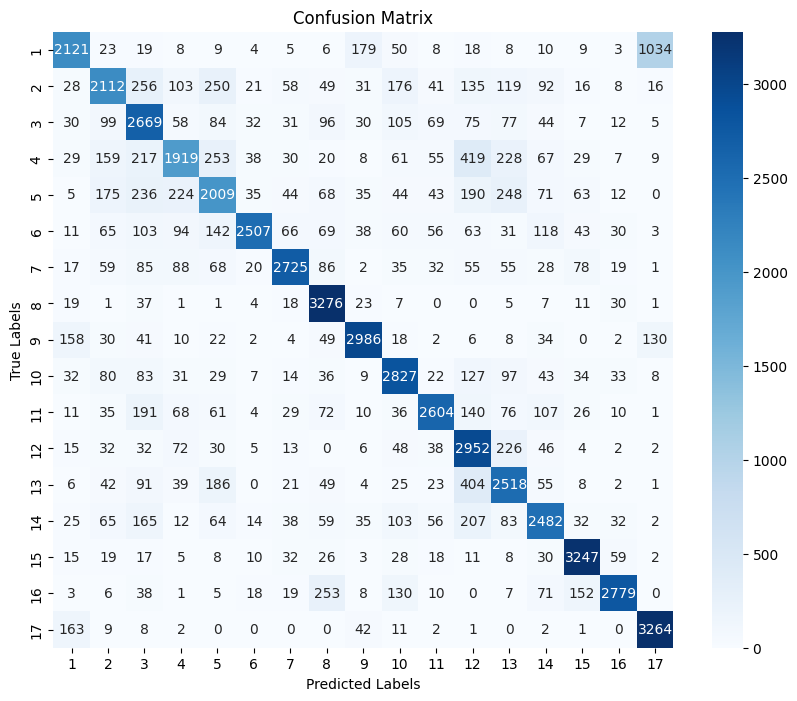

In [70]:
## TRAIN DATA
# 
y_pred = model.predict(X_train_trimmed_norm)
y_pred_classes = np.argmax(y_pred, axis=-1)
y_true_classes = np.argmax(y_train, axis=-1)
# Print classification report
print(classification_report(y_true_classes, y_pred_classes))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.72      0.56      0.63      1486
           1       0.57      0.48      0.52      1489
           2       0.55      0.65      0.60      1477
           3       0.59      0.44      0.50      1452
           4       0.50      0.47      0.48      1498
           5       0.85      0.62      0.72      1501
           6       0.80      0.73      0.76      1547
           7       0.76      0.91      0.83      1559
           8       0.82      0.80      0.81      1498
           9       0.66      0.74      0.70      1488
          10       0.78      0.67      0.72      1519
          11       0.55      0.75      0.63      1477
          12       0.56      0.64      0.60      1526
          13       0.67      0.63      0.65      1526
          14       0.80      0.87      0.84      1462
          15       0.84      0.74      0.79      1500
          16       0.72      0.91      0

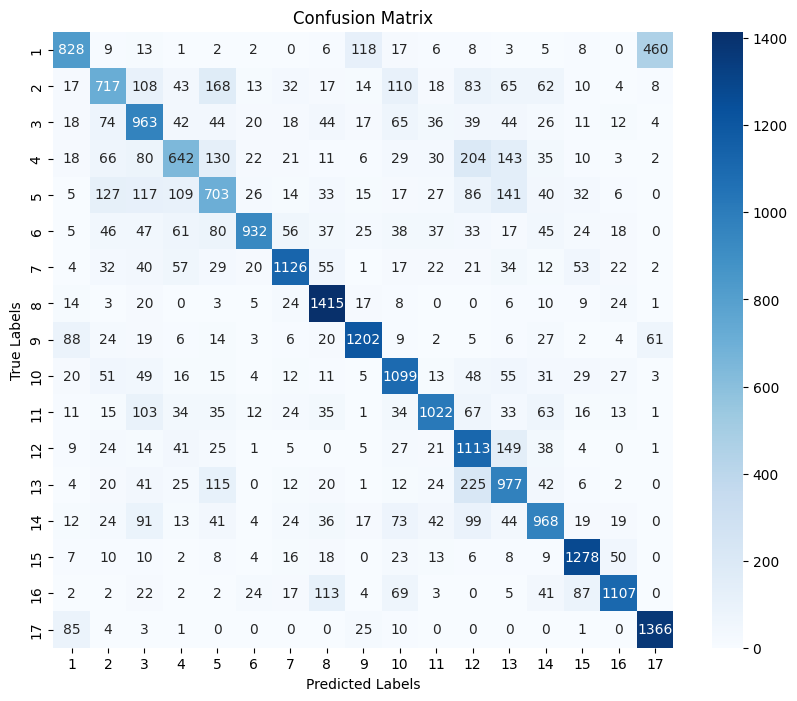

In [71]:
# Generate classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=-1)
y_true_classes = np.argmax(y_test, axis=-1)
# Print classification report
print(classification_report(y_true_classes, y_pred_classes))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

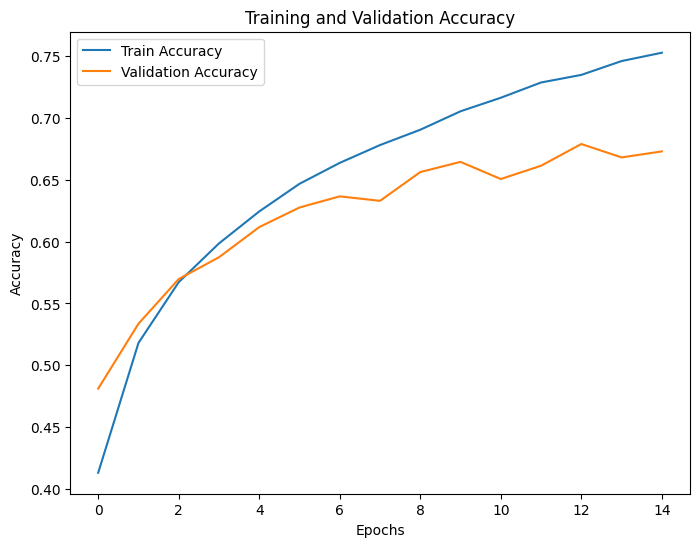

In [ ]:
# Plot training and validation accuracy
# history = model.history
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
